# Redes Neuronales con `make_moons`

Práctica completa siguiendo el ejercicio del PDF.

## Objetivo
Construir una red neuronal pequeña para clasificar el dataset `make_moons`, observar su entrenamiento, evaluar sus predicciones y visualizar la frontera de decisión.

### Flujo
1. Importar librerías  
2. Crear el dataset  
3. Explorar los datos  
4. Visualizar el problema  
5. Separar entrenamiento/prueba  
6. Escalar los datos  
7. Construir la red neuronal  
8. Compilar  
9. Entrenar  
10. Analizar el aprendizaje  
11. Generar predicciones  
12. Calcular métricas  
13. Matriz de confusión  
14. Frontera de decisión  
15. Comparar umbrales


## Paso 1 — Importar librerías y fijar semillas

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Semillas para reproducibilidad
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)
print("Librerías cargadas correctamente.")


TensorFlow: 2.20.0
Librerías cargadas correctamente.


## Paso 2 — Crear el dataset

Se generan **1,000 observaciones**, con `noise=0.20` y `random_state=42`.  
Las dos variables de entrada serán `x1` y `x2`, y la variable objetivo será `clase`.


In [ ]:
X, y = make_moons(
    n_samples=1000,
    noise=0.20,
    random_state=42
)

df = pd.DataFrame(X, columns=["x1", "x2"])
df["clase"] = y

print("Dimensiones del dataset:", df.shape)
display(df.head())

print("\nValores presentes en la variable objetivo:")
print(sorted(df["clase"].unique()))


Dimensiones del dataset: (1000, 3)


,x1,x2,clase
0,-0.111667,0.520224,1
1,1.142650,-0.342577,1
2,0.795558,-0.011442,1
3,0.111827,-0.551932,1
4,-0.816466,0.543996,0



Valores presentes en la variable objetivo:
[np.int64(0), np.int64(1)]


## Paso 3 — Explorar los datos

In [ ]:
print("=== Información del DataFrame ===")
df.info()

print("\n=== Valores nulos ===")
print(df.isnull().sum())

print("\n=== Conteo de clases ===")
print(df["clase"].value_counts().sort_index())

print("\n=== Proporción de clases ===")
print(df["clase"].value_counts(normalize=True).sort_index())


=== Información del DataFrame ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      1000 non-null   float64
 1   x2      1000 non-null   float64
 2   clase   1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB

=== Valores nulos ===
x1       0
x2       0
clase    0
dtype: int64

=== Conteo de clases ===
clase
0    500
1    500
Name: count, dtype: int64

=== Proporción de clases ===
clase
0    0.5
1    0.5
Name: proportion, dtype: float64


### Interpretación del paso 3

El dataset tiene **1,000 observaciones** y no debería presentar valores nulos.  
Las clases están balanceadas: aproximadamente 50% pertenecen a la clase 0 y 50% a la clase 1.

Esto facilita la interpretación inicial del `accuracy`, porque no existe una clase claramente mayoritaria.

**¿Qué pasaría si estuviera desbalanceado?**  
Un modelo podría obtener un accuracy aparentemente alto simplemente prediciendo casi siempre la clase mayoritaria. En ese caso sería especialmente importante revisar métricas como `precision`, `recall` y `F1-score`.


## Paso 4 — Visualizar el problema

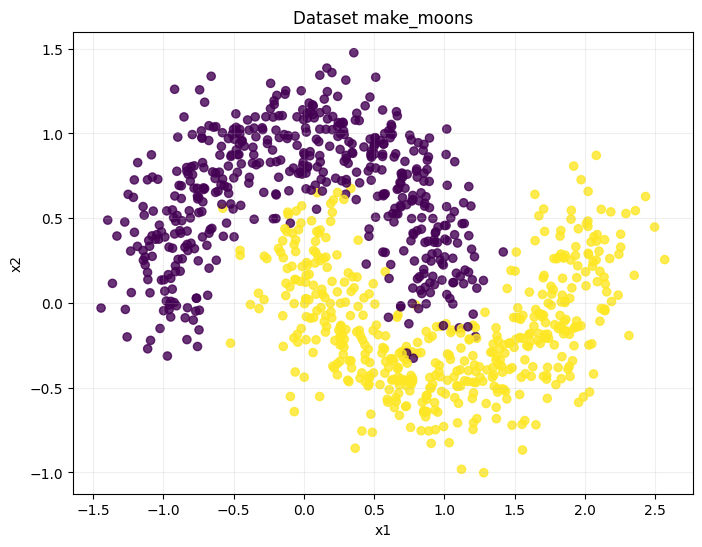

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(
    df["x1"],
    df["x2"],
    c=df["clase"],
    cmap="viridis",
    s=35,
    alpha=0.8
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Dataset make_moons")
plt.grid(alpha=0.2)
plt.show()


### Reflexión

Los dos grupos forman un patrón de **dos lunas entrelazadas**, por lo que no pueden separarse perfectamente utilizando solamente una línea recta.

Esto justifica utilizar una red neuronal con **capas ocultas** y funciones de activación **no lineales** como ReLU.


## Paso 5 — Separar entrenamiento y prueba

In [ ]:
X = df[["x1", "x2"]].values
y = df["clase"].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nDistribución en entrenamiento:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())

print("\nDistribución en prueba:")
print(pd.Series(y_test).value_counts(normalize=True).sort_index())


X_train: (800, 2)
X_test : (200, 2)
y_train: (800,)
y_test : (200,)

Distribución en entrenamiento:
0    0.5
1    0.5
Name: proportion, dtype: float64

Distribución en prueba:
0    0.5
1    0.5
Name: proportion, dtype: float64


### ¿Por qué usar `stratify=y`?

Porque conserva aproximadamente la misma proporción de clases en entrenamiento y prueba.  
Así evitamos que una partición aleatoria deje demasiados ejemplos de una clase en un conjunto y muy pocos en el otro.


## Paso 6 — Escalar los datos con `StandardScaler`

In [ ]:
scaler = StandardScaler()

# El escalador se ajusta SOLO con entrenamiento.
X_train_scaled = scaler.fit_transform(X_train)

# En prueba únicamente se transforma.
X_test_scaled = scaler.transform(X_test)

print("Primeras 5 filas ANTES del escalado:")
display(pd.DataFrame(X_train[:5], columns=["x1", "x2"]))

print("Primeras 5 filas DESPUÉS del escalado:")
display(pd.DataFrame(X_train_scaled[:5], columns=["x1", "x2"]))


Primeras 5 filas ANTES del escalado:


,x1,x2
0,0.219693,-0.221667
1,0.478288,0.724277
2,2.176120,0.262044
3,-0.787853,-0.101121
4,1.940766,-0.106134


Primeras 5 filas DESPUÉS del escalado:


,x1,x2
0,-0.311813,-0.886809
1,-0.021605,0.910056
2,1.883783,0.032022
3,-1.442530,-0.657826
4,1.619657,-0.667349


El escalador se ajusta únicamente con los datos de entrenamiento para evitar **fuga de información (`data leakage`)** desde el conjunto de prueba.


## Paso 7 — Construir la red neuronal

In [ ]:
model = Sequential([
    Input(shape=(2,)),
    Dense(8, activation="relu"),
    Dense(4, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

### Arquitectura

- **Entrada:** 2 variables (`x1`, `x2`)
- **Capa oculta 1:** 8 neuronas, ReLU
- **Capa oculta 2:** 4 neuronas, ReLU
- **Salida:** 1 neurona, Sigmoid

La salida Sigmoid produce una probabilidad entre 0 y 1.

La red debe tener **65 parámetros entrenables**. Los números 8 y 4 representan neuronas internas, no columnas adicionales del dataset.


## Paso 8 — Compilar la red

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Modelo compilado.")


Modelo compilado.


En este punto todavía no se entrena la red.  
Solo se definen las reglas del aprendizaje:

- `binary_crossentropy`: mide el error para clasificación binaria.
- `adam`: actualiza los pesos.
- `accuracy`: mide la proporción de predicciones correctas.


## Paso 9 — Entrenar la red

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

print("Épocas ejecutadas:", len(history.history["loss"]))


Épocas ejecutadas: 100


Durante el entrenamiento ocurre repetidamente:

1. **Forward pass:** la red calcula una predicción.
2. **Cálculo de pérdida:** se mide el error.
3. **Backpropagation:** se calcula cómo contribuyó cada peso al error.
4. **Ajuste:** el optimizador actualiza los pesos.


## Paso 10 — Observar cómo aprendió la red

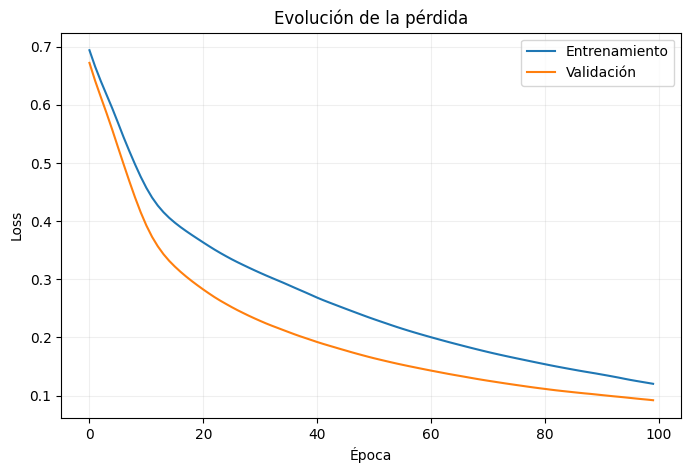

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Entrenamiento")
plt.plot(history.history["val_loss"], label="Validación")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Evolución de la pérdida")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


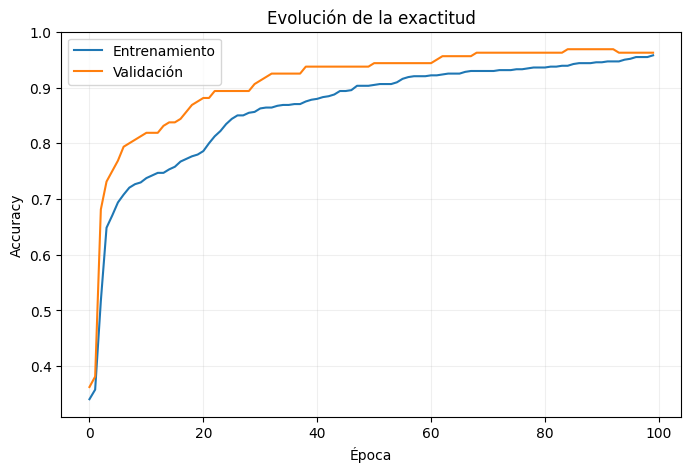

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Entrenamiento")
plt.plot(history.history["val_accuracy"], label="Validación")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Evolución de la exactitud")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


### Interpretación

- Si el `loss` baja, el modelo está reduciendo su error.
- Si el `accuracy` sube, el modelo clasifica correctamente más observaciones.
- Si entrenamiento sigue mejorando pero validación empeora de forma persistente, habría indicios de **sobreajuste**.


## Paso 11 — Probabilidades y predicciones

In [ ]:
y_prob = model.predict(X_test_scaled, verbose=0).ravel()

umbral = 0.50
y_pred = (y_prob >= umbral).astype(int)

resultados = pd.DataFrame({
    "Real": y_test,
    "Probabilidad_clase_1": y_prob,
    "Prediccion": y_pred
})

display(resultados.head(15))


,Real,Probabilidad_clase_1,Prediccion
0,1,0.915411,1
1,0,0.005369,0
2,0,0.006970,0
3,0,0.036510,0
4,1,0.964145,1
5,1,0.934836,1
6,1,0.999824,1
7,1,0.978368,1
8,0,0.048276,0
9,0,0.118702,0


La red produce primero una **probabilidad**.  
Después, aplicamos un umbral de `0.50`:

- Probabilidad < 0.50 → clase 0
- Probabilidad ≥ 0.50 → clase 1


## Paso 12 — Calcular métricas

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metricas = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Valor": [accuracy, precision, recall, f1]
})

display(metricas)


,Métrica,Valor
0,Accuracy,0.975000
1,Precision,0.979798
2,Recall,0.970000
3,F1-score,0.974874


### Significado de las métricas

- **Accuracy:** proporción total de predicciones correctas.
- **Precision:** de los casos predichos como clase 1, cuántos realmente eran clase 1.
- **Recall:** de los casos que realmente eran clase 1, cuántos detectó la red.
- **F1-score:** combina Precision y Recall en una sola medida.


## Paso 13 — Matriz de confusión

Array de la matriz de confusión:
[[98  2]
 [ 3 97]]


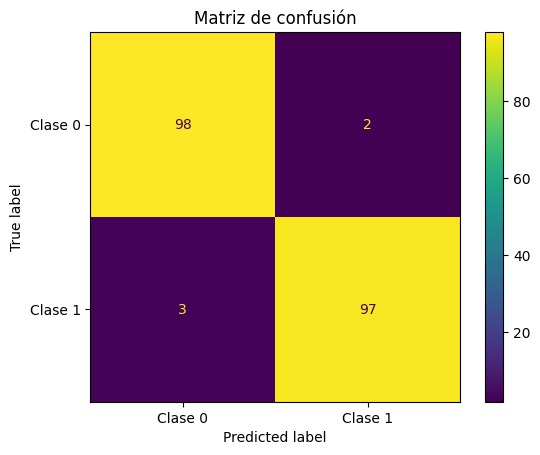

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Array de la matriz de confusión:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Clase 0", "Clase 1"]
)

disp.plot(cmap="viridis")
plt.title("Matriz de confusión")
plt.grid(False)
plt.show()


In [ ]:
tn, fp, fn, tp = cm.ravel()

print("Verdaderos negativos (VN):", tn)
print("Falsos positivos (FP):", fp)
print("Falsos negativos (FN):", fn)
print("Verdaderos positivos (VP):", tp)


Verdaderos negativos (VN): 98
Falsos positivos (FP): 2
Falsos negativos (FN): 3
Verdaderos positivos (VP): 97


La matriz de confusión permite ver **qué tipo de errores** comete el modelo, no solo cuántos.

En el material de referencia se muestra como ejemplo una ejecución con resultados cercanos a 98% de acierto, pero los valores exactos pueden variar ligeramente entre ejecuciones y versiones de TensorFlow.


## Paso 14 — Visualizar la frontera de decisión

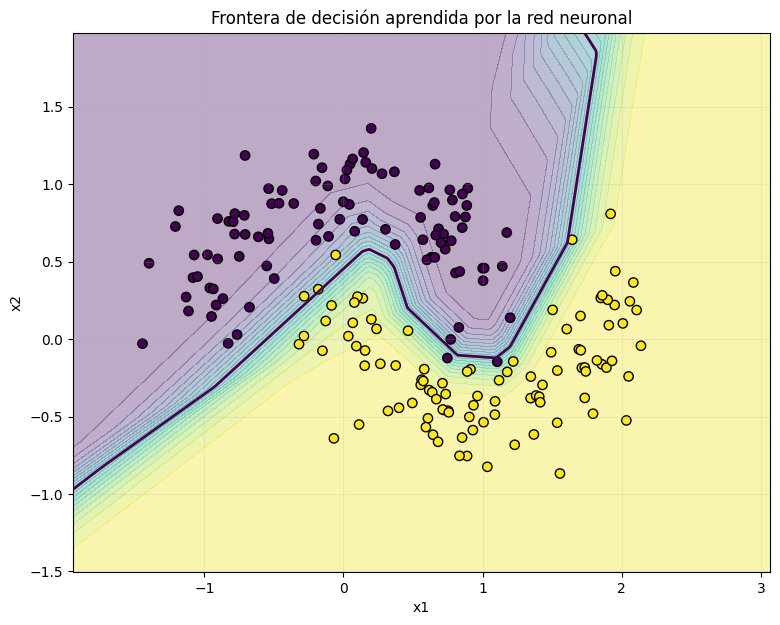

In [ ]:
# Rango de la malla en el espacio ORIGINAL de x1 y x2
x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x1_min, x1_max, 300),
    np.linspace(x2_min, x2_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

# IMPORTANTE: usar el mismo scaler ya ajustado.
grid_scaled = scaler.transform(grid)

grid_prob = model.predict(grid_scaled, verbose=0).reshape(xx.shape)

plt.figure(figsize=(9, 7))

# Regiones de probabilidad
plt.contourf(
    xx,
    yy,
    grid_prob,
    levels=np.linspace(0, 1, 21),
    cmap="viridis",
    alpha=0.35
)

# Línea de decisión en 0.50
plt.contour(
    xx,
    yy,
    grid_prob,
    levels=[0.50],
    linewidths=2
)

# Puntos de prueba en coordenadas originales
plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    cmap="viridis",
    edgecolor="black",
    s=45
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Frontera de decisión aprendida por la red neuronal")
plt.grid(alpha=0.2)
plt.show()


La frontera es **curva**, lo que muestra que la red aprendió una separación no lineal compatible con la forma de las dos lunas.


## Paso 15 — Comparar diferentes umbrales

In [ ]:
umbrales = [0.30, 0.50, 0.70]
filas = []

for u in umbrales:
    pred_u = (y_prob >= u).astype(int)

    filas.append({
        "Umbral": u,
        "Accuracy": accuracy_score(y_test, pred_u),
        "Precision": precision_score(y_test, pred_u),
        "Recall": recall_score(y_test, pred_u),
        "F1-score": f1_score(y_test, pred_u)
    })

comparacion_umbrales = pd.DataFrame(filas)
display(comparacion_umbrales)


,Umbral,Accuracy,Precision,Recall,F1-score
0,0.3,0.980,0.970588,0.99,0.980198
1,0.5,0.975,0.979798,0.97,0.974874
2,0.7,0.980,1.000000,0.96,0.979592


### Interpretación del cambio de umbral

- Con un **umbral bajo** como `0.30`, es más fácil clasificar un caso como clase 1. Esto normalmente aumenta el **Recall**, aunque puede reducir la **Precision**.
- Con `0.50` se utiliza el punto de corte estándar.
- Con un **umbral alto** como `0.70`, se exige más seguridad antes de clasificar un caso como clase 1. Esto normalmente aumenta la **Precision**, pero puede disminuir el **Recall**.

No existe un umbral universalmente correcto. La mejor elección depende del costo de cada tipo de error.


# Conclusiones de la práctica

### 1. ¿Qué forma tienen los datos?
Los datos forman dos grupos con forma de lunas entrelazadas. La separación entre las clases es no lineal.

### 2. ¿Por qué se utilizó esta arquitectura?
Se usaron dos variables de entrada, dos capas ocultas de 8 y 4 neuronas con ReLU y una salida Sigmoid. Las capas ocultas y ReLU permiten aprender patrones no lineales.

### 3. ¿Cuántas épocas se ejecutaron?
El número real aparece en la salida de `len(history.history["loss"])`. Puede llegar a 100 o detenerse antes si `EarlyStopping` detecta que `val_loss` deja de mejorar.

### 4. ¿Qué ocurrió con el `loss`?
Durante el aprendizaje, el `loss` debe disminuir porque la red va ajustando sus pesos para reducir el error.

### 5. ¿Cómo se comportó la validación?
Debe compararse con entrenamiento. Si ambas curvas evolucionan de manera parecida, el modelo generaliza de forma razonable. Si entrenamiento mejora mientras validación empeora, habría sobreajuste.

### 6. ¿Qué produce realmente la red?
La neurona de salida produce una probabilidad entre 0 y 1. La clase final se obtiene aplicando un umbral.

### 7. ¿Qué aporta la matriz de confusión?
Permite distinguir verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos, mostrando exactamente qué errores cometió la red.

### 8. ¿Qué muestra la frontera de decisión?
Muestra visualmente cómo la red divide el espacio de las variables `x1` y `x2`. Al ser una frontera curva, confirma que el modelo aprendió una separación no lineal.

### 9. ¿Qué efecto tiene cambiar el umbral?
Modificar el umbral cambia el equilibrio entre `Precision` y `Recall`. Un umbral menor suele detectar más positivos, mientras que uno mayor exige más seguridad para asignar la clase 1.

## Conclusión general

Esta práctica muestra el proceso completo de una red neuronal: preparar los datos, entrenar el modelo, revisar su aprendizaje, evaluar sus predicciones y observar visualmente la frontera que aprendió. El dataset `make_moons` demuestra por qué una red neuronal puede ser útil cuando la relación entre las clases no puede describirse adecuadamente con una separación lineal.
